# 06 — Deep Learning Analysis

**Music Genre Classification Using Audio Signal Processing and Deep Learning**

This notebook analyzes the completed CNN experiments on the GTZAN test set.

### Final CNN
- Log-Mel spectrogram input
- Sample rate: 22,050 Hz
- 2-second audio segments
- 64 mel bins
- FFT size: 512
- Hop length: 256
- Adam optimizer
- Learning rate: 0.001
- Dropout: 0.30
- Batch size: 32
- Best epoch: 27

### Final results
- **Test Accuracy: 56.67%**
- **Test Macro-F1: 0.5443**
- **Best Validation Accuracy: 58.67%**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Deep Learning Analysis — ready.")

Deep Learning Analysis — ready.


## 1. Baseline vs Best CNN

The baseline CNN achieved 54.00% test accuracy and 0.5304 Macro-F1. The final selected CNN achieved 56.67% test accuracy and 0.5443 Macro-F1.

In [2]:
baseline_accuracy = 0.5400
baseline_f1 = 0.5304
final_accuracy = 0.5667
final_f1 = 0.5443

comparison = pd.DataFrame({
    "Model": ["CNN Baseline", "Best CNN"],
    "Test Accuracy": [baseline_accuracy, final_accuracy],
    "Macro-F1": [baseline_f1, final_f1]
})

print(comparison.to_string(index=False))
print(f"\nAccuracy improvement: {(final_accuracy-baseline_accuracy)*100:.2f} percentage points")
print(f"Macro-F1 improvement: {final_f1-baseline_f1:.4f}")

       Model  Test Accuracy  Macro-F1
CNN Baseline         0.5400    0.5304
    Best CNN         0.5667    0.5443

Accuracy improvement: 2.67 percentage points
Macro-F1 improvement: 0.0139


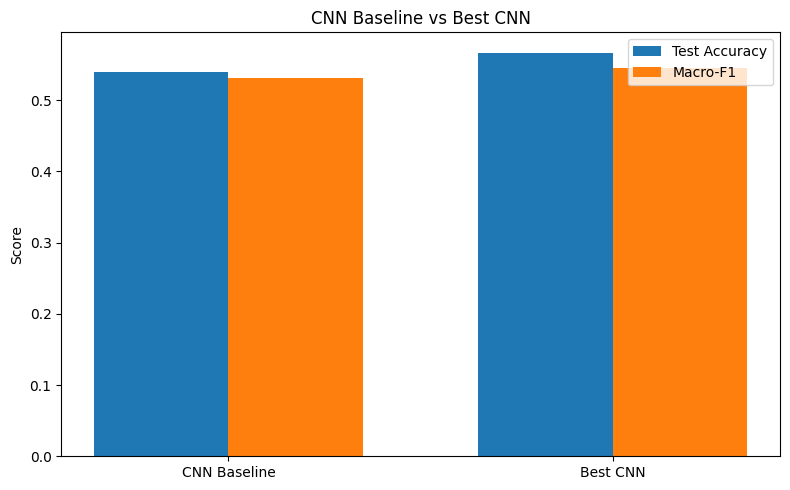

In [3]:
x = np.arange(len(comparison))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, comparison["Test Accuracy"], width, label="Test Accuracy")
plt.bar(x + width/2, comparison["Macro-F1"], width, label="Macro-F1")
plt.xticks(x, comparison["Model"])
plt.ylabel("Score")
plt.title("CNN Baseline vs Best CNN")
plt.legend()
plt.tight_layout()
plt.show()

## 2. Hyperparameter Tuning

Model selection was based on validation accuracy. The selected configuration was learning rate 0.001, dropout 0.30, and batch size 32.

In [4]:
tuning_results = pd.DataFrame([
    ["Baseline", 0.001, 0.30, 32, 0.520000, 0.480000, 0.450544],
    ["Low LR", 0.0005, 0.30, 32, 0.506667, 0.520000, 0.485316],
    ["High Dropout", 0.001, 0.50, 32, 0.486667, 0.420000, 0.344682],
    ["Larger Batch", 0.001, 0.30, 64, 0.486667, 0.486667, 0.459377],
    ["Low LR + High Dropout", 0.0005, 0.50, 32, 0.413333, 0.386667, 0.312881]
], columns=["Experiment","Learning Rate","Dropout","Batch Size","Validation Accuracy","Test Accuracy","Test Macro-F1"])

print(tuning_results.to_string(index=False))

           Experiment  Learning Rate  Dropout  Batch Size  Validation Accuracy  Test Accuracy  Test Macro-F1
             Baseline         0.0010      0.3          32             0.520000       0.480000       0.450544
               Low LR         0.0005      0.3          32             0.506667       0.520000       0.485316
         High Dropout         0.0010      0.5          32             0.486667       0.420000       0.344682
         Larger Batch         0.0010      0.3          64             0.486667       0.486667       0.459377
Low LR + High Dropout         0.0005      0.5          32             0.413333       0.386667       0.312881


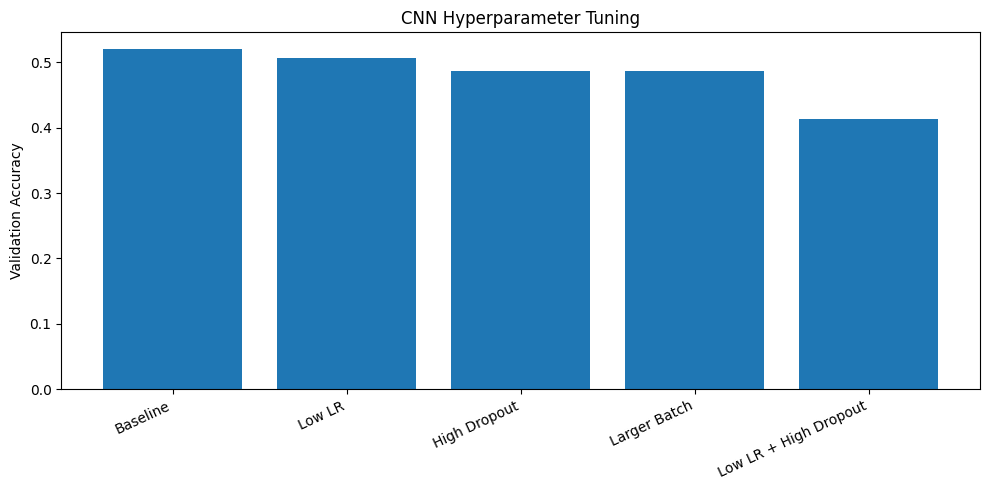

In [5]:
plt.figure(figsize=(10, 5))
plt.bar(tuning_results["Experiment"], tuning_results["Validation Accuracy"])
plt.ylabel("Validation Accuracy")
plt.title("CNN Hyperparameter Tuning")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 3. Final Configuration

The final CNN used log-mel spectrograms from two-second clips. The best validation accuracy was 58.67% at epoch 27.

In [6]:
final_configuration = pd.DataFrame({
    "Parameter": ["Representation","Sample Rate","Duration","Mel Bins","FFT Size","Hop Length","Optimizer","Learning Rate","Dropout","Batch Size","Best Epoch"],
    "Value": ["Log-Mel Spectrogram",22050,"2 seconds",64,512,256,"Adam",0.001,0.30,32,27]
})
print(final_configuration.to_string(index=False))

     Parameter               Value
Representation Log-Mel Spectrogram
   Sample Rate               22050
      Duration           2 seconds
      Mel Bins                  64
      FFT Size                 512
    Hop Length                 256
     Optimizer                Adam
 Learning Rate               0.001
       Dropout                 0.3
    Batch Size                  32
    Best Epoch                  27


## 4. Final Test Confusion Matrix

The matrix below is the actual matrix produced by the completed final CNN run. Each genre has 15 test examples.

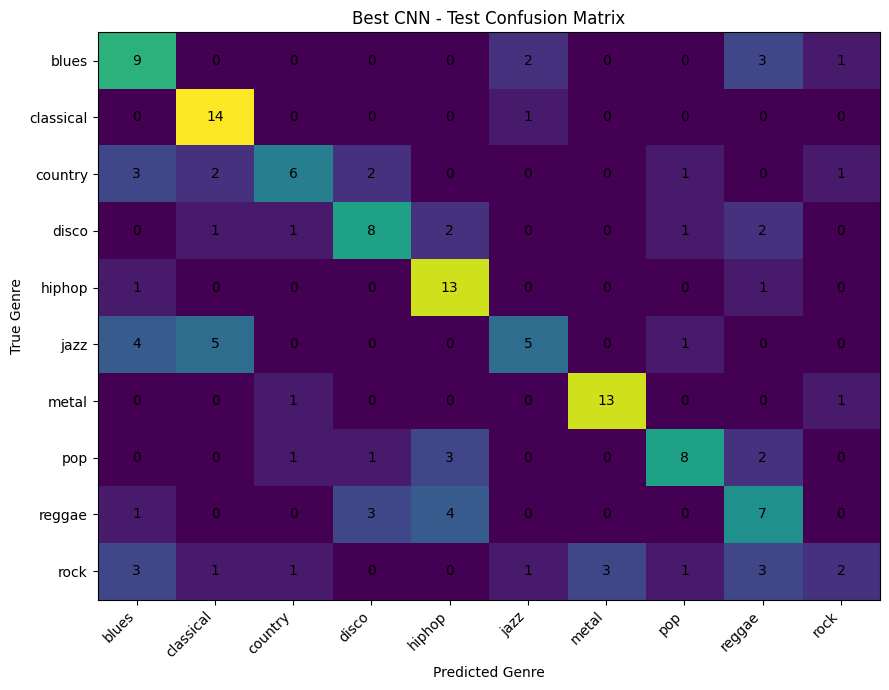

In [7]:
genres = ["blues","classical","country","disco","hiphop","jazz","metal","pop","reggae","rock"]

cm = np.array([
    [9,0,0,0,0,2,0,0,3,1],
    [0,14,0,0,0,1,0,0,0,0],
    [3,2,6,2,0,0,0,1,0,1],
    [0,1,1,8,2,0,0,1,2,0],
    [1,0,0,0,13,0,0,0,1,0],
    [4,5,0,0,0,5,0,1,0,0],
    [0,0,1,0,0,0,13,0,0,1],
    [0,0,1,1,3,0,0,8,2,0],
    [1,0,0,3,4,0,0,0,7,0],
    [3,1,1,0,0,1,3,1,3,2]
])

plt.figure(figsize=(9,7))
plt.imshow(cm, aspect="auto")
plt.title("Best CNN - Test Confusion Matrix")
plt.xlabel("Predicted Genre")
plt.ylabel("True Genre")
plt.xticks(range(10), genres, rotation=45, ha="right")
plt.yticks(range(10), genres)

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i,j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [8]:
recall = np.diag(cm) / cm.sum(axis=1)

genre_performance = pd.DataFrame({
    "Genre": genres,
    "Correct": np.diag(cm),
    "Total": cm.sum(axis=1),
    "Recall": recall
}).sort_values("Recall")

print("GENRE PERFORMANCE")
print(genre_performance.to_string(index=False))

print("\nHARDEST GENRES")
print(genre_performance.head(3).to_string(index=False))

print("\nBEST-PERFORMING GENRES")
print(genre_performance.sort_values("Recall", ascending=False).head(3).to_string(index=False))

GENRE PERFORMANCE
    Genre  Correct  Total   Recall
     rock        2     15 0.133333
     jazz        5     15 0.333333
  country        6     15 0.400000
   reggae        7     15 0.466667
      pop        8     15 0.533333
    disco        8     15 0.533333
    blues        9     15 0.600000
   hiphop       13     15 0.866667
    metal       13     15 0.866667
classical       14     15 0.933333

HARDEST GENRES
  Genre  Correct  Total   Recall
   rock        2     15 0.133333
   jazz        5     15 0.333333
country        6     15 0.400000

BEST-PERFORMING GENRES
    Genre  Correct  Total   Recall
classical       14     15 0.933333
   hiphop       13     15 0.866667
    metal       13     15 0.866667


In [9]:
confusions = []

for i in range(10):
    for j in range(10):
        if i != j and cm[i,j] > 0:
            confusions.append({
                "True Genre": genres[i],
                "Predicted Genre": genres[j],
                "Count": int(cm[i,j])
            })

confusions_df = pd.DataFrame(confusions).sort_values("Count", ascending=False)
print("TOP GENRE CONFUSIONS")
print(confusions_df.head(10).to_string(index=False))

TOP GENRE CONFUSIONS
True Genre Predicted Genre  Count
      jazz       classical      5
      jazz           blues      4
    reggae          hiphop      4
      rock          reggae      3
      rock           blues      3
     blues          reggae      3
   country           blues      3
       pop          hiphop      3
      rock           metal      3
    reggae           disco      3


## 5. Deep Learning Findings

### Audio representation
Log-mel spectrograms convert the audio signal into a time-frequency representation that is suitable for convolutional feature extraction.

### Hyperparameter tuning
The selected configuration used a learning rate of 0.001, dropout of 0.30, and batch size 32. The stronger dropout and lower learning-rate configurations tested here reduced validation performance.

### Baseline vs final model
The final CNN improved test accuracy from **54.00% to 56.67%**, a **2.67 percentage-point improvement**. Macro-F1 increased from **0.5304 to 0.5443**.

### Error analysis
The final confusion matrix shows substantial differences between genres. Classical achieved 14/15 correct, while hip-hop and metal each achieved 13/15. Rock was the most difficult class with 2/15 correct, followed by jazz with 5/15.

Common confusions include rock with blues/metal/reggae, jazz with classical/blues, and reggae with hip-hop/disco.

### Limitation
The model uses only two-second excerpts. A short segment may not contain enough rhythmic, harmonic, vocal, or instrumental information to represent the full track.

### Future work
Potential extensions include longer temporal context, CNN-RNN/GRU/LSTM architectures, transfer learning, and richer audio representations.

In [10]:
summary = pd.DataFrame({
    "Metric": [
        "Baseline Test Accuracy","Best CNN Test Accuracy","Accuracy Improvement",
        "Baseline Macro-F1","Best CNN Macro-F1","Best Validation Accuracy","Best Epoch"
    ],
    "Value": [
        "54.00%","56.67%","+2.67 percentage points",
        "0.5304","0.5443","58.67%","27"
    ]
})

print(summary.to_string(index=False))
print("\n" + "="*60)
print("DEEP LEARNING ANALYSIS COMPLETE")
print("="*60)

                  Metric                   Value
  Baseline Test Accuracy                  54.00%
  Best CNN Test Accuracy                  56.67%
    Accuracy Improvement +2.67 percentage points
       Baseline Macro-F1                  0.5304
       Best CNN Macro-F1                  0.5443
Best Validation Accuracy                  58.67%
              Best Epoch                      27

DEEP LEARNING ANALYSIS COMPLETE
